# Home Exercise on Neural Network
> Implement a Neural Network model using fully **connected layers**, **non-linear activation**, **skip connections**, **dropout**, etc. (Note that you are *only allowed to use MLP blocks and must not use CNNs, Transformers, or other advanced deep learning architectures*) (Can train on a 10GB GPU ). 

Data: [MNIST datasets](https://www.kaggle.com/competitions/digit-recognizer/data) 

In [2]:
!kaggle competitions download -c digit-recognizer

Traceback (most recent call last):
  File "/home/dikhang/miniconda3/envs/llms/bin/kaggle", line 3, in <module>
    from kaggle.cli import main
  File "/home/dikhang/miniconda3/envs/llms/lib/python3.11/site-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/home/dikhang/miniconda3/envs/llms/lib/python3.11/site-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /home/dikhang/.config/kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [7]:
import os, shutil
import zipfile
import numpy as np
import pandas as pd

## Load the dataset

In [8]:
import zipfile
def unzip_file(path, des, delete=True):
    if not os.path.exists(path) or not os.path.exists(des):
        print(f"Error: Source folder '{path}' not found.")
        return
    with zipfile.ZipFile(path) as zipref:
        zipref.extractall(des)
        print(f"Extracted zipfile in {des}")
    if delete:
        os.remove(path)
        return
    
data_dir = "./data"
zip_path = os.path.join(data_dir, "digit-recognizer.zip")
unzip_file(zip_path, data_dir, True)

Error: Source folder './data/digit-recognizer.zip' not found.


In [9]:
print(os.listdir(data_dir))

['sample_submission.csv', 'test.csv', 'train.csv']


In [10]:
train_path = os.path.join(data_dir,"train.csv")
test_path = os.path.join(data_dir,"test.csv")
train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

In [11]:
print(train_data.columns)

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)


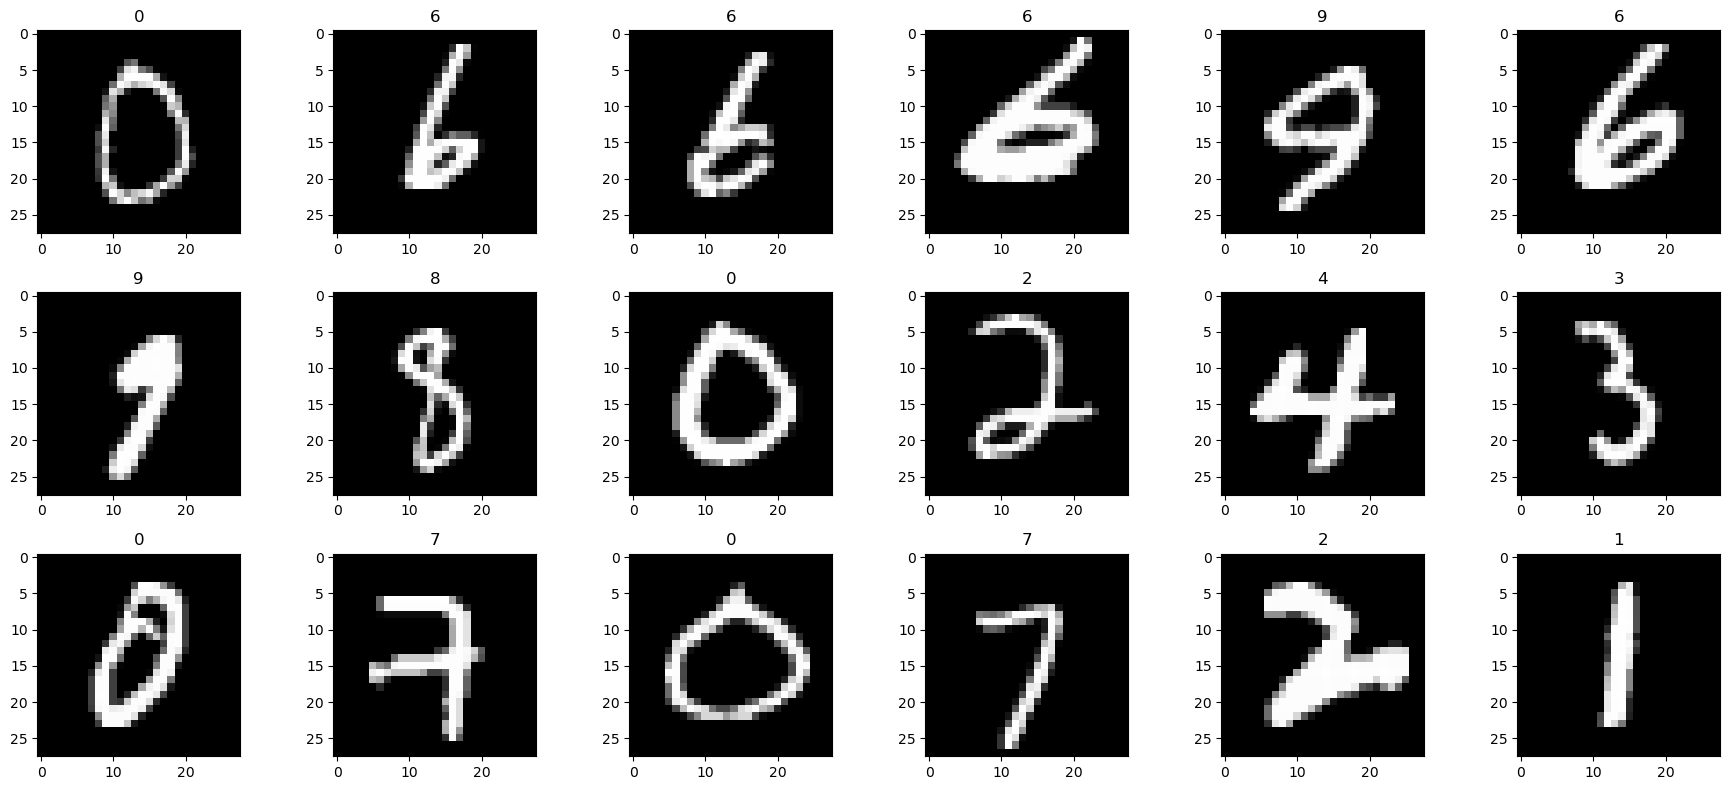

In [12]:
import matplotlib.pyplot as plt
def show_image(train_image, label, index):
    image_shaped = train_image.values.reshape(28,28)
    plt.subplot(3, 6, index+1)
    plt.imshow(image_shaped, cmap=plt.cm.gray)
    plt.title(label)


plt.figure(figsize=(18, 8))
sample_image = train_data.sample(18).reset_index(drop=True)
for index, row in sample_image.iterrows():
    label = row['label']
    image_pixels = row.drop('label')
    show_image(image_pixels, label, index)
plt.tight_layout()